<a href="https://colab.research.google.com/github/franciscalorraynes/redes_neurais_01/blob/main/prova_redes_neurais.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import kagglehub
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt


In [ ]:
# Download latest version
path = kagglehub.dataset_download("soroushsaadat81/parkinsons-telemonitoring")

print("Path to dataset files:", path)

100%|██████████| 292k/292k [00:00<00:00, 46.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/soroushsaadat81/parkinsons-telemonitoring/versions/1


In [ ]:
file = os.path.join(path, "parkinsons_updrs.data")

df = pd.read_csv(file)

#exibir
df.head()

,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,1,72,0,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,...,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,1,72,0,12.6660,28.447,34.894,0.00300,0.000017,0.00132,0.00150,...,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,1,72,0,19.6810,28.695,35.389,0.00481,0.000025,0.00205,0.00208,...,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,1,72,0,25.6470,28.905,35.810,0.00528,0.000027,0.00191,0.00264,...,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,1,72,0,33.6420,29.187,36.375,0.00335,0.000020,0.00093,0.00130,...,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361


In [ ]:
features = [
    'age',
    'sex',
    'test_time',
    'Jitter(%)',
    'Jitter(Abs)',
    'Jitter:RAP',
    'Jitter:PPQ5',
    'Jitter:DDP',
    'Shimmer',
    'Shimmer(dB)',
    'Shimmer:APQ3',
    'Shimmer:APQ5',
    'Shimmer:APQ11',
    'Shimmer:DDA',
    'NHR',
    'HNR',
    'RPDE',
    'DFA',
    'PPE'
]

X = df[features]
y = df['motor_UPDRS']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1)
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,905 (15.25 KB)

 Trainable params: 3,905 (15.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse',  metrics=['mae'])

In [ ]:
history = model.fit(X_train, y_train, validation_split=0.2, epochs=100, batch_size=32)

Epoch 1/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 299.6797 - mae: 14.5822 - val_loss: 107.5123 - val_mae: 8.3574
Epoch 2/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 85.3668 - mae: 7.4346 - val_loss: 68.1241 - val_mae: 6.8393
Epoch 3/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 63.7933 - mae: 6.5768 - val_loss: 57.5865 - val_mae: 6.3589
Epoch 4/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 56.1589 - mae: 6.1835 - val_loss: 51.9276 - val_mae: 5.9341
Epoch 5/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 52.2070 - mae: 5.9614 - val_loss: 48.9277 - val_mae: 5.7733
Epoch 6/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 47.9691 - mae: 5.7149 - val_loss: 44.8416 - val_mae: 5.5051
Epoch 7/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 44.0651 - mae: 5.4395 - val_loss: 42.0271 - val_mae: 5.3717
Epoch 8/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 40.1998 - mae: 5.1905 - val_loss: 38.5710 - val_mae: 5.0669
Epoch 9/100
118/118 ━━━━━━━━━

In [ ]:
y_pred = model.predict(X_test).flatten()

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MAE: 2.9924
MSE: 18.0019
RMSE: 4.2429
R²: 0.7180


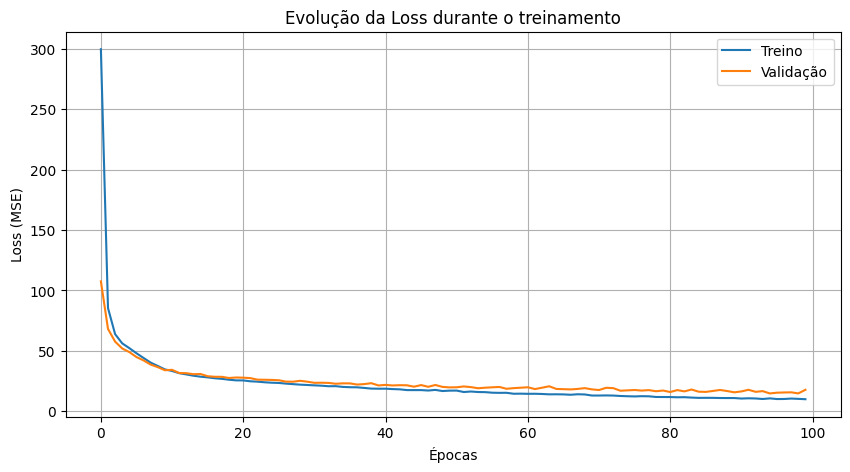

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')

plt.xlabel('Épocas')
plt.ylabel('Loss (MSE)')
plt.title('Evolução da Loss durante o treinamento')
plt.legend()
plt.grid()

plt.show()

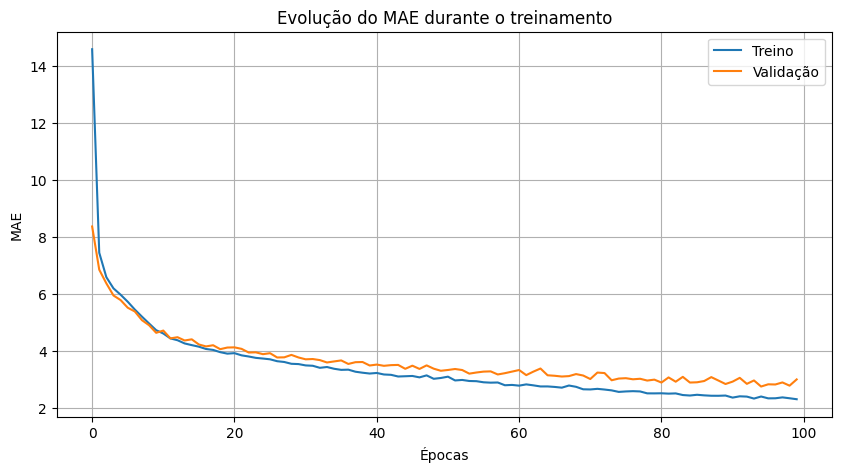

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(history.history['mae'], label='Treino')
plt.plot(history.history['val_mae'], label='Validação')

plt.xlabel('Épocas')
plt.ylabel('MAE')
plt.title('Evolução do MAE durante o treinamento')
plt.legend()
plt.grid()

plt.show()

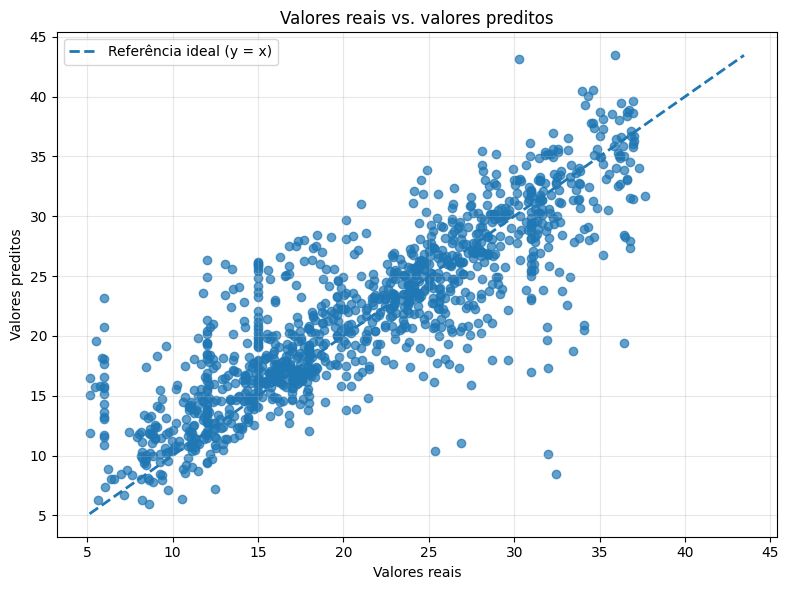

In [ ]:
plt.figure(figsize=(8, 6))

# Valores reais x valores preditos
plt.scatter(y_test, y_pred, alpha=0.7)

# Linha de referência ideal: y = x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--',
    linewidth=2,
    label='Referência ideal (y = x)'
)

plt.xlabel('Valores reais')
plt.ylabel('Valores preditos')
plt.title('Valores reais vs. valores preditos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
model.save('parkinsons_model.keras')
print('Model saved.')

Model saved.


In [ ]:
indice = 0

valor_real = y_test.iloc[indice]

valor_previsto = y_pred[indice]

print("Valor real:", valor_real)
print("Valor previsto:", valor_previsto)
print("Erro:", abs(valor_real - valor_previsto))

Valor real: 33.084
Valor previsto: 22.556662
Erro: 10.527338394165042


In [ ]:
resultados = pd.DataFrame({
    'Real': y_test.values,
    'Previsto': y_pred
})

resultados['Erro'] = abs(resultados['Real'] - resultados['Previsto'])

print(resultados.head(10))

      Real   Previsto       Erro
0  33.0840  22.556662  10.527338
1   7.1599   6.746648   0.413252
2  11.2180  12.452000   1.234000
3  12.7590  13.098072   0.339072
4  25.3910  21.055771   4.335229
5  18.0000  19.223055   1.223055
6  11.4840  19.808617   8.324617
7  25.2360  28.754416   3.518416
8  17.9280  13.791027   4.136973
9  28.0920  26.986734   1.105266
